In [43]:
#!pip install pyDOE
#!pip install tensorflow
#!pip install pydot
#!pip install graphviz

In [44]:
import tensorflow as tf
import numpy as np
from pyDOE import lhs
import matplotlib.pyplot as plt
import pydot
import graphviz
import math
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import time
import random

In [45]:
tf.keras.backend.set_floatx('float64')

In [46]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
tf.config.list_physical_devices('GPU')
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

Num GPUs Available:  0
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 12953614516666950278
xla_global_id: -1
]


In [47]:
# Initial condition
x0, y0 = np.log(0.9), np.log(0.9)


# Boundaries of the computational domain
t0, tfinal = 0.0, 36

In [48]:
decimal_p = 4

In [49]:
a = 2/3
b = 4/3
c = 1
d = 1

In [50]:
v0 = (c * (math.exp(x0))) - (d * x0) + (b * math.exp(y0)) - (a * y0)

print(v0)

2.275600859429711


In [51]:
with open('LV 2,3 4,3 1 1 0.9 0.9 0 36 0.0001.npy', 'rb') as f:

    points = np.load(f)

tpoints = points[0]
tpoints = np.round(tpoints, decimal_p)
xpoints = points[1]
ypoints = points[2]

In [52]:
# Define the normalization layer
class Normalize(tf.keras.layers.Layer):
  def __init__(self, xmin, xmax, name=None, **kwargs):
    super(Normalize, self).__init__(name=name)
    self.xmin = xmin
    self.xmax = xmax
    super(Normalize, self).__init__(**kwargs)

  def call(self, inputs):
    return 2.0*(inputs-self.xmin)/(self.xmax-self.xmin)-1.0

  def get_config(self):
    config = super(Normalize, self).get_config()
    config.update({'xmin': self.xmin, 'xmax': self.xmax})
    return config

In [53]:
# Define the network
def build_model(nr_units=40, nr_layers=4, summary=False):

  inp = b = tf.keras.layers.Input(shape=(1,), name = "Input_t")
  b = Normalize(t0, tfinal)(b)
  Normalize.name  = "Normalize"

  for i in range(nr_layers):
    b = tf.keras.layers.Dense(nr_units, activation='tanh', name = "Hidden_" + str(i))(b)
    print("b", b)
  outx = tf.keras.layers.Dense(1, activation='linear', name = "Output_x")(b)
  outy = tf.keras.layers.Dense(1, activation='linear', name = "Output_y")(b)

  model = tf.keras.models.Model(inp, [outx, outy])
  
  if summary:
    model.summary()

  return model

b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float64, name=None), name='Hidden_0/Tanh:0', description="created by layer 'Hidden_0'")
b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float64, name=None), name='Hidden_1/Tanh:0', description="created by layer 'Hidden_1'")
b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float64, name=None), name='Hidden_2/Tanh:0', description="created by layer 'Hidden_2'")
b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float64, name=None), name='Hidden_3/Tanh:0', description="created by layer 'Hidden_3'")
Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 Input_t (InputLayer)           [(None, 1)]          0           []                               
                                                                                      

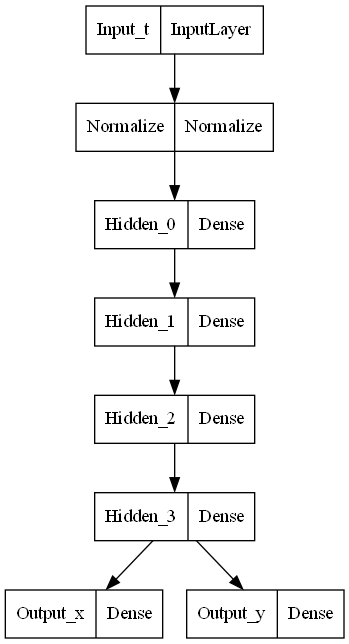

In [54]:
model = build_model(summary = True)
tf.keras.utils.plot_model(model)

In [55]:
# Define the collocation points over the domain [t_0, t_1]
def defineCollocationPoints(t_bdry, N_pde=100):

    # Sample points where to evaluate the PDE
  ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N_pde)

  return ode_points

Text(0.5, 1.0, 'Collocation points being used')

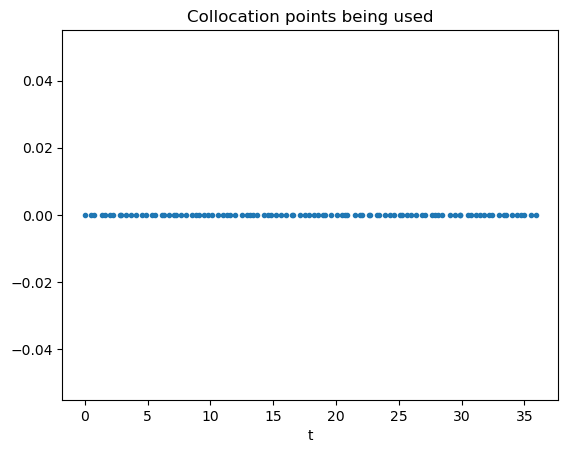

In [56]:
# Define the collocation points

de_points = defineCollocationPoints([t0, tfinal], 100)
de_points_tensor = tf.convert_to_tensor(de_points, dtype=tf.float32)
plt.plot(de_points[:,0], 0*de_points[:,0],'.')
plt.xlabel('t')
plt.title('Collocation points being used')

In [57]:
# The main training function
@tf.function
def train_network(model, t, inits, alpha, beta, gamma):

    t_de = t

    # Initial value points
    t_init, x_init, y_init = inits[:, 0], inits[:, 1], inits[:, 2]
    

    # Outer gradient for tuning network parameters
    with tf.GradientTape() as tape:

      # Inner gradient for derivatives of u wrt x and t
      with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(t_de)
        [x, y] = model(t_de, training=True)
        v = (c * (tf.math.exp(x))) - (d * x) + (b * tf.math.exp(y)) - (a * y)
        
      # Derivative of the neural network solution
      xt = tape2.gradient(x, t_de)
      yt = tape2.gradient(y, t_de)

      #xt = tf.cast(xt, tf.float32)
      #yt = tf.cast(yt, tf.float32)
        

      # Define the differential equation loss  
      eqn1 = xt - a + b*(tf.math.exp(y))
      eqn2 = yt - c*(tf.math.exp(x)) + d
      DEloss = tf.reduce_mean(tf.square(eqn1) + tf.square(eqn2))
                         
      # Define the initial value loss
      [x_init_pred, y_init_pred] = model(t_init, training=True)
      IVloss = tf.reduce_mean(tf.square(x_init_pred - x_init) + tf.square(y_init_pred - y_init))
    
    
      #Implicit integration loss
      vt = tape2.gradient(v, t_de)
      tf.print(vt)
      #v = (c * (tf.math.exp(x))) - (d * x) + (b * tf.math.exp(y)) - (a * y)
    
      Vloss = tf.square(tf.math.reduce_mean(v) - v0)           
    
      # Composite loss function
      loss = alpha*DEloss + beta*IVloss + gamma*Vloss

    grads = tape.gradient(loss, model.trainable_variables)
    
    return DEloss, IVloss, Vloss, grads

In [58]:
def PINNtrain(custom_model, custom_t, x0, y0, epochs, alpha_val, beta_val, gamma_val):

    # Weight factors
    alpha = alpha_val
    beta = beta_val
    gamma = gamma_val

    # Learning rate
    lr_model = 1e-2

    # Initial value
    t_init = np.array([t0]).astype(np.float64)
    x_init = np.array([x0]).astype(np.float64)
    y_init = np.array([y0]).astype(np.float64)
                                                                    
    
    inits = np.column_stack([t_init, x_init, y_init])

    epoch_loss = np.zeros(epochs)

    # Generate the model
    opt = tf.keras.optimizers.Adam(lr_model)

    # Main training loop
    for i in range(epochs):

        # Train the network
        DEloss, IVloss, Vloss, grads = train_network(custom_model, custom_t, inits, alpha, beta, gamma)

        # Gradient step
        opt.apply_gradients(zip(grads, custom_model.trainable_variables))
      
        epoch_loss[i] += alpha*DEloss + beta*IVloss + gamma*Vloss

        if (np.mod(i, 100)==0) :
            
            print("Dloss, Iloss, Closs in {}th epoch: {: 6.4f}, {: 6.4f}, {: 6.4f}.".format(i, DEloss, IVloss, Vloss))

    return epoch_loss, custom_model

In [59]:
colloc_points_per_cycle = 100
step_size = 0.001

In [60]:
def train_plot_sequential(custom_model, t_start, t_end, epochs, cycles, alpha, beta, gamma) :
    
    empty_arr = np.array([[]])
    
    x = tf.reshape(tf.convert_to_tensor(empty_arr, dtype=tf.float64), [0, 1])
    y = tf.reshape(tf.convert_to_tensor(empty_arr, dtype=tf.float64), [0, 1])

    t = np.arange(t_start, t_end, step_size)
    t = np.round(t, decimal_p)
    num_t = len(t)
    print("num t", num_t)
    
    delta_t = int((t_end - t_start)/cycles)
    
    print("colloc_points_per_cycle", colloc_points_per_cycle)
    print("delta_t", delta_t)

    loss_vals = np.zeros(epochs * cycles)
    next_model = custom_model
    
    next_x0 = x0
    next_y0 = y0
    
    custom_t = defineCollocationPoints([0.0, delta_t], colloc_points_per_cycle)
    
    t_pred = np.arange(0.0, delta_t, step_size)
    t_pred = np.round(t_pred, decimal_p)
    
    for i in range(cycles) :

        loss, model = PINNtrain(next_model, custom_t, next_x0, next_y0, epochs, alpha, beta, gamma)
        loss_vals[i*epochs : (i+1)*epochs] = loss
        
        [next_x, next_y] = model(t_pred, training=True)
        
        x = tf.concat([x, next_x], axis = 0)
        y = tf.concat([y, next_y], axis = 0)
        
        t_delta_t = np.array([delta_t]).astype(np.float64)
        
        [next_x0, next_y0] = model(t_delta_t, training=True)
        
        next_x0 = next_x0.numpy()[0][0]
        next_y0 = next_y0.numpy()[0][0]

        next_model = tf.keras.models.clone_model(model)
        next_model.build((None, 1))
        next_model.set_weights(model.get_weights())
        

    plt.figure(1)
    plt.semilogy(loss_vals)
    
    x = tf.math.exp(x)
    y = tf.math.exp(y)
    
    # Plot the solution
    print(len(x))
    
    plt.figure(2)
    #plt.plot(x, y, label = "e = " + str(epochs) + ", cycles = " + str(cycles))
    plt.plot(x, y, label = "e = " + str(epochs))
    plt.legend(loc='best')
    plt.plot(xpoints, ypoints, color = 'black')
    plt.xlabel("x")
    plt.ylabel("y")
    
    error = calc_err(t, x, y)
    print("error", error)
    print("error mean", error/num_t)
    
    plt.figure(3)
    plt.scatter(cycles, error)
    plt.xlabel("number of cycles")
    plt.ylabel("error")
    
    plt.figure(4)
    plt.plot(tpoints, xpoints, color = 'black')
    plt.plot(t, x, label = "e = " + str(epochs))
    plt.legend(loc='best')
    plt.xlabel("t")
    plt.ylabel("x")
    
    plt.figure(5)
    plt.plot(tpoints, ypoints, color = 'black')
    plt.plot(t, y, label = "e = " + str(epochs))
    plt.legend(loc='best')
    plt.xlabel("t")
    plt.ylabel("y")

In [61]:
def calc_err(t_preds, x_preds, y_preds) :
    
    error = 0
    
    for i in range(len(t_preds)) :
        
        t_i = np.where(tpoints == t_preds[i])
        
        err = math.sqrt((x_preds[i] - xpoints[t_i])**2 + (y_preds[i] - ypoints[t_i])**2)
        
        error = error + err
        
    return error

In [62]:
start = time.time()

In [63]:
# epochs = 500
# cycles = 4

custom_model = build_model(summary = False)
train_plot_sequential(custom_model, t0, tfinal, 5000, 1, 12, 1.2, 100.0)

custom_model = build_model(summary = False)
train_plot_sequential(custom_model, t0, tfinal, 10000, 1, 12, 1.2, 100.0)

custom_model = build_model(summary = False)
train_plot_sequential(custom_model, t0, tfinal, 15000, 1, 12, 1.2, 100.0)

b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float64, name=None), name='Hidden_0/Tanh:0', description="created by layer 'Hidden_0'")
b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float64, name=None), name='Hidden_1/Tanh:0', description="created by layer 'Hidden_1'")
b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float64, name=None), name='Hidden_2/Tanh:0', description="created by layer 'Hidden_2'")
b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float64, name=None), name='Hidden_3/Tanh:0', description="created by layer 'Hidden_3'")
num t 36000
colloc_points_per_cycle 100
delta_t 36
[[0.0027478244195755707]
 [0.0015493707640463598]
 [0.0018811321277922904]
 ...
 [0.0015237593421504841]
 [0.0021935666402288015]
 [0.0024896359450574113]]
Dloss, Iloss, Closs in 0th epoch:  0.4503,  0.0086,  0.0035.
[[-0.015562792325183455]
 [-0.089231811461844848]
 [0.018267327513768205]
 ...
 [-0.090118367213563769]
 [-0.061155242636762475]
 [0

[[0.014129035547207333]
 [-0.0063733634960281838]
 [0.01447464403046949]
 ...
 [-0.0067497051431397092]
 [0.003448599934947596]
 [0.016159281007578852]]
[[0.014365643432512253]
 [-0.0076913381279985586]
 [0.015115142984517757]
 ...
 [-0.0080933921805098029]
 [0.002824509721467942]
 [0.016735840637499878]]
[[0.014197760326514772]
 [-0.0091631620779647118]
 [0.015315277387271854]
 ...
 [-0.0095840414964103327]
 [0.0018954284080872456]
 [0.0168759877653812]]
[[0.01363913930171623]
 [-0.009270481346735306]
 [0.014827046373733166]
 ...
 [-0.0096796351396844244]
 [0.0015155271793115749]
 [0.01633050449491176]]
[[0.013084616469638722]
 [-0.0083872847710238715]
 [0.01411046293914078]
 ...
 [-0.0087695266022802861]
 [0.0017003910397710477]
 [0.015580227575216774]]
[[0.012900717100653852]
 [-0.0079027261719874179]
 [0.013807976711701447]
 ...
 [-0.0082731792610676071]
 [0.0018735513488902422]
 [0.015276183062018727]]
[[0.013113478498096645]
 [-0.0083390015270082482]
 [0.014088366235966647]
 ...


[[0.012978615899600207]
 [-0.0074166605747455908]
 [0.018688604974792643]
 ...
 [-0.007725740043329688]
 [0.0012180882018950215]
 [0.018196373556338477]]
[[0.0129470425752802]
 [-0.0073032402313544173]
 [0.018759113349392283]
 ...
 [-0.0076086246712744219]
 [0.0012468829785016278]
 [0.018201009839670736]]
[[0.01292969229306813]
 [-0.0073023709756161268]
 [0.018958046112516232]
 ...
 [-0.0076057362706164538]
 [0.0012091108309126015]
 [0.018294819558173494]]
[[0.012911490001202244]
 [-0.0073416186314167534]
 [0.019227984012224746]
 ...
 [-0.0076431610622559407]
 [0.0011384059227355068]
 [0.01843370932682338]]
[[0.012872856633531431]
 [-0.0072659539482949551]
 [0.019455754118498078]
 ...
 [-0.0075634008340275177]
 [0.0011204958482996122]
 [0.018530543314786724]]
[[0.012836892219928283]
 [-0.0071751413149831527]
 [0.019675635878377926]
 ...
 [-0.0074681224183147186]
 [0.0011095918079478658]
 [0.018623452597884522]]
[[0.012827726700542925]
 [-0.0072015588267407621]
 [0.019952419193501682]
 

[[0.0098071299129163427]
 [-0.0044633771370672067]
 [0.04268699967314589]
 ...
 [-0.004528641217559407]
 [-0.0020414356390227096]
 [0.030004542186437493]]
[[0.0094882791996206937]
 [-0.0043100132266138342]
 [0.043946828330779425]
 ...
 [-0.0043706945084278333]
 [-0.0020687906581527307]
 [0.030597237995036712]]
[[0.0091263646386913772]
 [-0.0042108792941451135]
 [0.045322563173760877]
 ...
 [-0.0042676797012595018]
 [-0.0021339483697423544]
 [0.031236926840533516]]
[[0.0087720160127668818]
 [-0.0040320105424174451]
 [0.046680404798107568]
 ...
 [-0.0040850748943927224]
 [-0.0021192557314215457]
 [0.031849919726526642]]
[[0.00834768509515953]
 [-0.00399007440738883]
 [0.048248367691432925]
 ...
 [-0.0040405604972319287]
 [-0.0022113178227799596]
 [0.032551615805466359]]
[[0.007999037877915555]
 [-0.0037059360648405834]
 [0.049631361404795696]
 ...
 [-0.0037532831644284978]
 [-0.0020788713972098344]
 [0.033138261207251281]]
[[0.0074187727310994359]
 [-0.0039287646394092074]
 [0.0516637188

[[0.0088803934324654474]
 [-0.0038770380019412104]
 [0.037705743100596573]
 ...
 [-0.0039229625257254626]
 [-0.002071523728508327]
 [0.03654856166976185]]
[[0.010018077390454464]
 [-0.0035229171700962014]
 [0.036183393673816434]
 ...
 [-0.0035708823116058727]
 [-0.001641866011901482]
 [0.038956509191505791]]
[[0.01047096400539509]
 [-0.003296520576670201]
 [0.035174886129739187]
 ...
 [-0.0033462914186731104]
 [-0.001373283369887013]
 [0.039323504849098773]]
[[0.00989655684973515]
 [-0.0032729533270923795]
 [0.035600057532984425]
 ...
 [-0.0033227784497532184]
 [-0.0013923426696414551]
 [0.038295705008219473]]
[[0.0085477422979328976]
 [-0.0034049999875203885]
 [0.0371081638710696]
 ...
 [-0.0034528834419610679]
 [-0.0016463245644987431]
 [0.036462255074768884]]
[[0.0070962533882449538]
 [-0.003587010443349155]
 [0.038842129093827504]
 ...
 [-0.0036322069970162]
 [-0.0019698584456373913]
 [0.034471635425294543]]
[[0.0060206490051982059]
 [-0.0037924381494353126]
 [0.040437925334908358]

...

[[0.00045169027519920347]
 [-0.0054208398714617563]
 [0.026435172781216189]
 ...
 [-0.006585780158673081]
 [-0.00023582881806718]
 [0.022600458984226596]]
[[0.00053131257514027626]
 [-0.0056868957745736188]
 [0.02427661680339949]
 ...
 [-0.0068009738365308846]
 [-0.0002575296569719895]
 [0.018525681877060472]]
[[0.00042994832832621559]
 [-0.0048921963000036839]
 [0.02837862542230447]
 ...
 [-0.0060300936444953332]
 [-0.00022421996966250917]
 [0.024417121406953745]]
[[0.0005674349298215338]
 [-0.0055239231326588128]
 [0.025687530436402206]
 ...
 [-0.0066009134786872495]
 [-0.00025494856032863344]
 [0.017395426326227759]]
[[0.00044579753114393824]
 [-0.0046925473339973845]
 [0.030411024006462967]
 ...
 [-0.005796470674097276]
 [-0.0002275373351426101]
 [0.023932786407436568]]
[[0.00055771288476750311]
 [-0.0051817853076328441]
 [0.027460570271836526]
 ...
 [-0.0062257353322256667]
 [-0.0002485137396283853]
 [0.018436174800354612]]
[[0.00047024874080089869]
 [-0.0046578207920451873]
 [0.0

[[0.00054318290564980246]
 [-0.0052744966948060721]
 [0.025317526200493237]
 ...
 [-0.0063531311239243132]
 [-0.00020943326974706857]
 [0.017581915077079045]]
[[0.00047350278715368045]
 [-0.0047680508458312317]
 [0.027712608166711453]
 ...
 [-0.0058823854530173914]
 [-0.00020437043653142223]
 [0.021977440813685873]]
[[0.00053221330758431037]
 [-0.0052538439973662436]
 [0.02462295101412321]
 ...
 [-0.0063320927073266279]
 [-0.00021337589880952127]
 [0.017424224488464219]]
[[0.00046207429079355626]
 [-0.0047163603541822922]
 [0.026711714587279969]
 ...
 [-0.0058349589387937141]
 [-0.00020535179793838813]
 [0.02212636195884073]]
[[0.0005383703341342251]
 [-0.0052629834552265576]
 [0.023412257621223787]
 ...
 [-0.0063517773033839806]
 [-0.00020711354676056966]
 [0.017098183792482798]]
[[0.00045896517760613388]
 [-0.0046546703629112675]
 [0.026221909912616005]
 ...
 [-0.0057866978359512261]
 [-0.00020078188288130935]
 [0.022440464246696098]]
[[0.00054469843227266529]
 [-0.005282808850406148

[[0.0006032358790109732]
 [-0.0054258581084986749]
 [0.026216075783881635]
 ...
 [-0.0064989073526080104]
 [-0.000194937539047725]
 [0.015345873020393943]]
[[0.00050294910919172872]
 [-0.0044171005443799632]
 [0.030273066144178379]
 ...
 [-0.0055268403164940982]
 [-0.00021244400466606419]
 [0.022941890202784414]]
[[0.00061993241011712289]
 [-0.0056346144100527839]
 [0.024374817155644959]
 ...
 [-0.0067158197157637716]
 [-0.00019187442835339342]
 [0.014098929572001945]]
Dloss, Iloss, Closs in 1100th epoch:  0.0060,  0.0106,  0.0000.
[[0.000484919810801525]
 [-0.004367657444082189]
 [0.029187647651110839]
 ...
 [-0.0055193521104971131]
 [-0.00021774256639109425]
 [0.024238592930068515]]
[[0.00062934720644798256]
 [-0.0060745374954575921]
 [0.021568746145899684]
 ...
 [-0.0072172475067848523]
 [-0.00019585918597763588]
 [0.012724448366607743]]
[[0.00047193368103061592]
 [-0.0046105557189554062]
 [0.027257807088197278]
 ...
 [-0.0058326349541007]
 [-0.00022722093374629807]
 [0.024683290502

[[0.00062654937317236964]
 [-0.006142713241646394]
 [0.02224279183710736]
 ...
 [-0.0072513019942230354]
 [-0.00017739284910003311]
 [0.013152637782968737]]
[[0.00054032435425745325]
 [-0.0048686569969597759]
 [0.027468696324281134]
 ...
 [-0.0059938584716681641]
 [-0.0002146366725326204]
 [0.021912923113375064]]
[[0.0006318638129062011]
 [-0.0064587129355921594]
 [0.022025590034317432]
 ...
 [-0.0075990074785811856]
 [-0.00017567884374405991]
 [0.011917728689622997]]
[[0.00053028737250764436]
 [-0.0049294436834191229]
 [0.028120720844913238]
 ...
 [-0.0060826351684982807]
 [-0.00022029551884891944]
 [0.022320619330867576]]
[[0.00063226374545961145]
 [-0.0066652684483258949]
 [0.022145187590051119]
 ...
 [-0.0078433742649010839]
 [-0.00017641390251056587]
 [0.011871673235258277]]
[[0.00053519694709048507]
 [-0.0052121760828879411]
 [0.027454804870279247]
 ...
 [-0.0063921090147793]
 [-0.00021983971392664574]
 [0.021793042728347003]]
[[0.00062246865155756023]
 [-0.0066022397426180272]
 

KeyboardInterrupt: 

In [ ]:
end = time.time()

print((end-start)/60)

In [ ]:
#     2 3 4

# 20 0.05328786159898205, 0.03248169943505809, 0.014598205832759456
# 30 0.060848330988604774, 0.019430389301504553, 0.0069668703920268285
# 40 0.03672581839745748, 0.00413 ,0.004484866589899533


